# Estudo do caso Banco Master / Vorcaro — tour didático

Notebook construído para **aprendizado**: cada seção tem explicação em texto e código pandas anotado. Cobre as 6 tabelas do `data/master.db` e cruza com a narrativa pública do caso (fontes em `DOCUMENTACAO.md`).

## Pré-requisitos

Antes de rodar, garanta que o pipeline foi executado:

```bash
python -m coleta.receita       # Fase 1
python -m grafo.b2b            # Fase 2
python -m db                   # consolida em SQLite
python -m coleta.cvm_diario    # informe diário FMP-FGTS
python -m coleta.cvm_sancoes   # processos sancionadores CVM
python -m coleta.cvm_carteira  # composição da carteira (CDA)
```

Se preferir só explorar, basta `data/master.db` existir.

## 1. Setup

Imports e configuração. Usa só **pandas + matplotlib** (deps padrão do `requirements.txt`).

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB = Path('data/master.db')
assert DB.exists(), f'master.db nao encontrado em {DB.resolve()} — rode o pipeline primeiro'

con = sqlite3.connect(DB)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'conectado em: {DB.resolve()}')

conectado em: C:\Users\carly\PycharmProjects\BancoMaster\data\master.db


## 2. Visão geral do dataset

Quantas linhas em cada tabela. Serve de sanidade — se algo der 0, é sinal de que falta rodar uma etapa do pipeline.

In [2]:
tabelas = [r[0] for r in con.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
).fetchall()]

resumo = []
for t in tabelas:
    if t.startswith('sqlite_'):
        continue
    n, = con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()
    resumo.append({'tabela': t, 'linhas': n})

pd.DataFrame(resumo)

,tabela,linhas
0,carteira,36
1,cvm_acusados,1934
2,cvm_processos,543
3,empresas,100
4,inf_diario,517
5,papeis_fundo,156
6,participacoes,164
7,pessoas,104


**Esperado** depois do pipeline completo:

- `empresas` ~100
- `pessoas` ~104
- `participacoes` ~164
- `papeis_fundo` ~156
- `inf_diario` ~517 (4 FMP-FGTS × ~130 dias úteis)
- `cvm_processos` ~543
- `cvm_acusados` ~1934
- `carteira` variável (depende de quantos meses do CDA foram coletados)

## 3. Empresas — o universo cadastrado

Cada empresa veio de uma de quatro fontes:

- `minha_receita`: seed direta consultada (47 CNPJs)
- `minha_receita_qsa`: apareceu como sócia PJ no QSA de uma seed (BFS profundidade 1-2)
- `cvm`: fundo registrado no `cad_fi.csv` da CVM com vínculo Master
- `cvm_papel`: entidade referenciada como prestador (admin/gestor/custodiante)


In [3]:
empresas = pd.read_sql('SELECT * FROM empresas', con)
print(f'total: {len(empresas)} empresas')
empresas['fonte'].value_counts()

total: 100 empresas


fonte
cvm                  52
minha_receita        28
minha_receita_qsa    19
cvm_papel             1
Name: count, dtype: int64

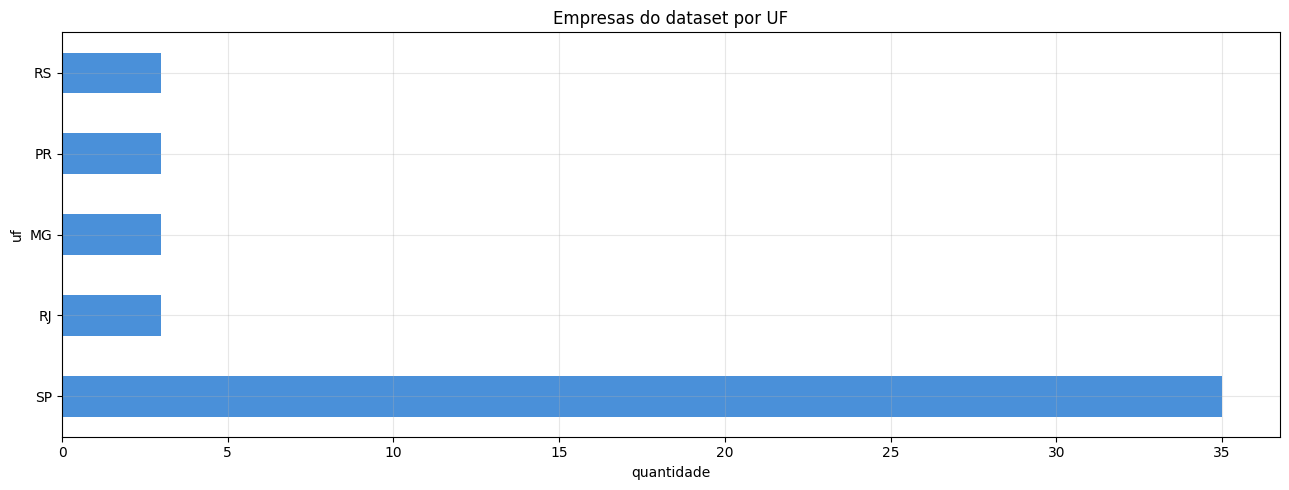


O Banco Master S/A está em RJ; Master Corretora em SP; Viking (holding pessoal) em MG.


In [4]:
uf_counts = empresas[empresas['uf'].notna() & (empresas['uf'] != '')]['uf'].value_counts()
ax = uf_counts.plot(kind='barh', color='#4A90D9')
ax.set_title('Empresas do dataset por UF')
ax.set_xlabel('quantidade')
plt.tight_layout()
plt.show()

print('\nO Banco Master S/A está em RJ; Master Corretora em SP; Viking (holding pessoal) em MG.')

## 4. Pessoas — quem aparece no QSA

Cada pessoa física no `pessoas` veio de algum QSA da Receita. CPFs vêm mascarados pela origem (`***xxxxxx**`) — usamos o nome como identificador. Risco de homônimo existe mas é baixo nas figuras-chave.

In [5]:
pessoas = pd.read_sql('SELECT * FROM pessoas', con)
print(f'total: {len(pessoas)} pessoas físicas')
print('\ndistribuição por faixa etária:')
pessoas['faixa_etaria'].value_counts(dropna=False)

total: 104 pessoas físicas

distribuição por faixa etária:


faixa_etaria
Entre 41 a 50 anos    36
Entre 31 a 40 anos    24
Entre 51 a 60 anos    21
Entre 61 a 70 anos    10
Entre 21 a 30 anos     7
Entre 71 a 80 anos     5
Maiores de 80 anos     1
Name: count, dtype: int64

In [6]:
ranking = pd.read_sql('''
    SELECT s.nome,
           COUNT(DISTINCT p.empresa_cnpj) AS n_empresas,
           GROUP_CONCAT(DISTINCT p.qualificacao) AS cargos
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    GROUP BY s.nome
    ORDER BY n_empresas DESC
    LIMIT 15
''', con)
ranking

,nome,n_empresas,cargos
0,ALEXANDRE JORGE CHAIA,4,"Administrador,Sócio-Administrador"
1,ANGELO ANTONIO RIBEIRO DA SILVA,4,Diretor
2,GUSTAVO AUGUSTO VASCONCELOS BIAVA,4,"Sócio-Administrador,Administrador"
3,JOSE ROBERTO GIANCOLI FILHO,4,"Sócio-Administrador,Administrador"
4,LUIZ ANTONIO BULL,4,"Diretor,Presidente"
5,ADEMIR SILVA OLIVEIRA,3,"Administrador,Sócio-Administrador"
6,DANIEL BUENO VORCARO,3,"Presidente,Sócio"
7,GUARACI SILLOS MOREIRA,3,"Administrador,Sócio,Sócio-Administrador"
8,MAURICIO ANTONIO QUADRADO,3,"Presidente,Sócio,Diretor"
9,RENATA FERRAZ DE ANDRADE DE ALMEIDA SOUZA,3,"Administrador,Sócio-Administrador"


**Como ler:** quem aparece em mais empresas é geralmente **diretor profissional** (precisa assinar atos em cada CNPJ). Vorcaro aparece em 3 lugares porque é Presidente nominalmente nominado + sócio único da Viking — controle se exerce pela **propriedade**, não pela assinatura. Veja a discussão no apêndice 4.15 do `RELATORIO.md`.

## 5. Participações — sócio → empresa ao longo do tempo

É na tabela `participacoes` que mora a **camada temporal** mais rica do QSA: cada linha tem `data_entrada`. Isso permite plotar a **frequência de mexidas societárias** ao longo do tempo.

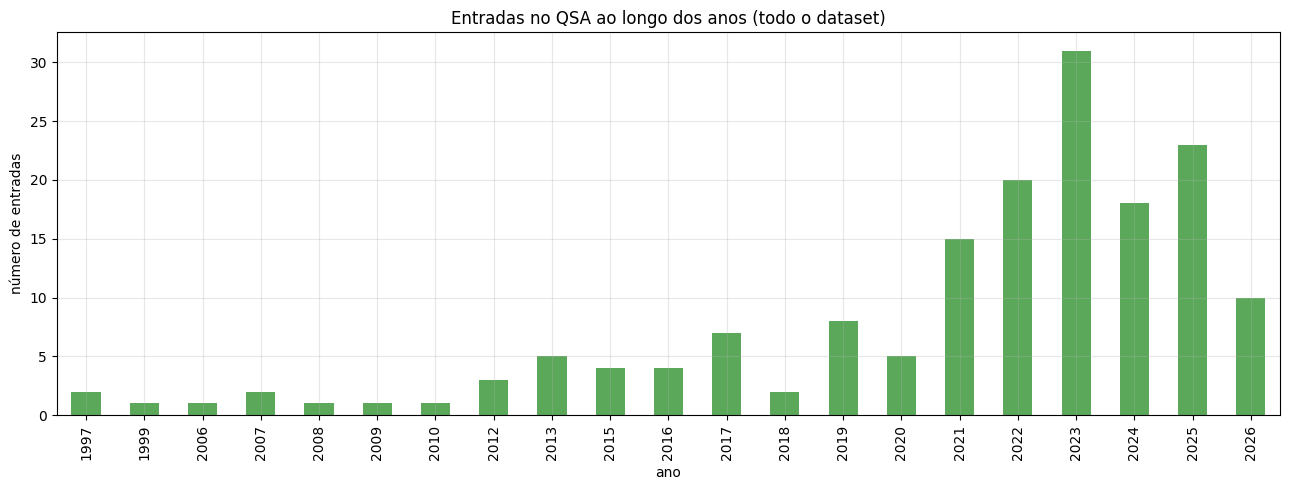

Atenção ao pico recente — convergente com o cronograma de degradação pré-liquidação.


In [7]:
part = pd.read_sql('''
    SELECT p.data_entrada, e.razao_social,
           COALESCE(s.nome, soc.razao_social) AS socio,
           CASE WHEN p.socio_pessoa_id > 0 THEN 'PF' ELSE 'PJ' END AS tipo,
           p.qualificacao
    FROM participacoes p
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    LEFT JOIN pessoas s ON s.id = p.socio_pessoa_id
    LEFT JOIN empresas soc ON soc.cnpj = p.socio_empresa_cnpj
    WHERE p.data_entrada != ''
''', con)
part['data_entrada'] = pd.to_datetime(part['data_entrada'], errors='coerce')
part['ano'] = part['data_entrada'].dt.year

por_ano = part.groupby('ano').size()
ax = por_ano.plot(kind='bar', color='#5BA85A')
ax.set_title('Entradas no QSA ao longo dos anos (todo o dataset)')
ax.set_ylabel('número de entradas')
ax.set_xlabel('ano')
plt.tight_layout()
plt.show()

print('Atenção ao pico recente — convergente com o cronograma de degradação pré-liquidação.')

In [8]:
movs_2025 = part[part['data_entrada'] >= '2025-01-01'].sort_values('data_entrada')
print(f'Mexidas societárias em 2025-2026: {len(movs_2025)}')
movs_2025[['data_entrada', 'socio', 'tipo', 'qualificacao', 'razao_social']]

Mexidas societárias em 2025-2026: 33


,data_entrada,socio,tipo,qualificacao,razao_social
54,2025-01-15,LUIZ ANTONIO CARDOSO,PF,Sócio-Administrador,"BRAVA GESTORA DE RECURSOS, CONSULTORIA E PARTICIPACOES LTDA"
36,2025-01-20,ANDRE TAVARES CASTANHEIRA,PF,Diretor,TERCON INVESTIMENTOS S.A.
115,2025-01-22,ACQUA&CO CAPITAL LTDA,PJ,Sócio,VANQUISH INVESTIMENTOS E PARTICIPACOES LTDA
105,2025-03-17,BRUNO CUNHA ALMEIDA,PF,Diretor,BANCO PAULISTA S.A.
131,2025-03-26,S.F. ASSESSORIA EMPRESARIAL E PARTICIPACOES LTDA,PJ,Sócio,CARMEL CAPITAL PARTICIPACOES LTDA
90,2025-05-05,ALEXANDRE MARCHESANI CANATA,PF,Administrador,AXOR ASSET LTDA
103,2025-06-13,ROGERIO PENTEADO FELGUEIRAS,PF,Administrador,TRUSTEE DISTRIBUIDORA DE TITULOS E VALORES MOBILIARIOS LTDA
158,2025-06-25,VICTOR DIRENE CHAIA,PF,Sócio,S.F. ASSESSORIA EMPRESARIAL E PARTICIPACOES LTDA
157,2025-06-25,GIOVANA DIRENE CHAIA,PF,Sócio,S.F. ASSESSORIA EMPRESARIAL E PARTICIPACOES LTDA
51,2025-07-01,RICARDO SILVA VASCONCELLOS,PF,Administrador,ACURA GESTORA DE RECURSOS LTDA.


**Pontos críticos visíveis:**

- **12/08/2025** — Vorcaro vira Presidente do Banco Master de Investimento (centralização)
- **29/09/2025** — STERN FIP entra na Viking + Adriano Garzon vira Administrador (blindagem)
- Em paralelo, fora do QSA: a liquidação BACEN acontece em **18/11/2025**

## 6. Fundos e papéis CVM

57 fundos têm vínculo Master via algum dos 4 papéis CVM. Vamos ver a distribuição.

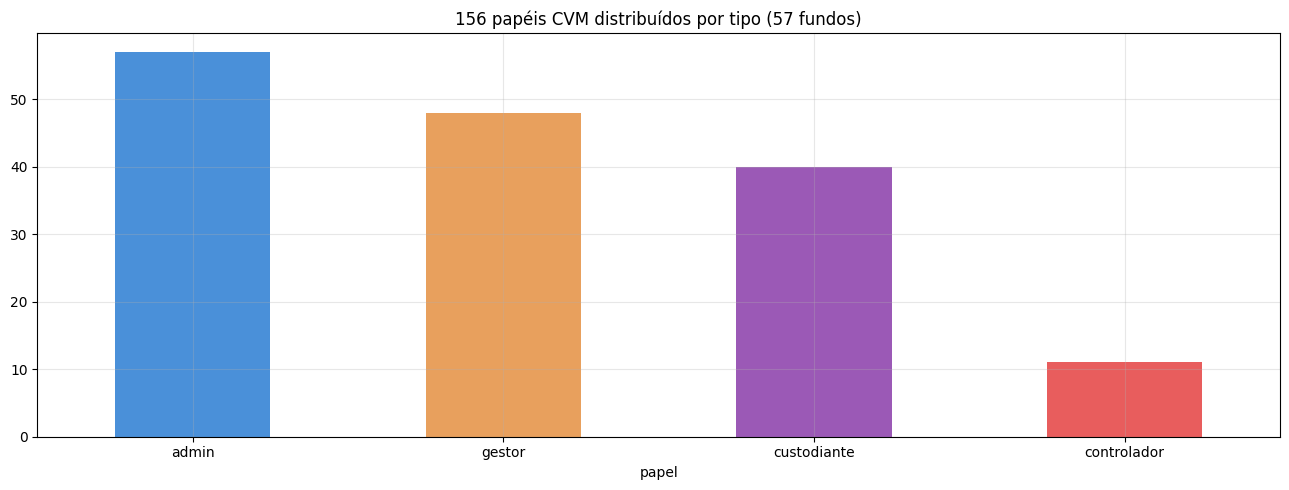

In [9]:
papeis = pd.read_sql('SELECT * FROM papeis_fundo', con)
papeis['papel'].value_counts().plot(kind='bar', color=['#4A90D9','#E8A05D','#9B59B6','#E85D5D'])
plt.title('156 papéis CVM distribuídos por tipo (57 fundos)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
gestoras = pd.read_sql('''
    SELECT prestador_nome, COUNT(*) AS n_fundos
    FROM papeis_fundo
    WHERE papel = 'gestor' AND prestador_nome IS NOT NULL
    GROUP BY prestador_nome
    ORDER BY n_fundos DESC
    LIMIT 12
''', con)
gestoras

,prestador_nome,n_fundos
0,MÁXIMA ASSET MANAGEMENT LTDA,11
1,CATÁLISE INVESTIMENTOS LTDA.,7
2,TERCON INVESTIMENTOS LTDA,5
3,MAM ASSET MANAGEMENT GESTORA DE RECURSOS LTDA.,5
4,ACURA GESTORA DE RECURSOS LTDA,3
5,SQUALO CAPITAL GESTORA DE RECURSOS LTDA,2
6,HARBOUR CAPITAL ADMINISTRADORA DE CARTEIRAS DE VALORES MOBILIÁRIOS LTDA.,2
7,GLOBAL GESTÃO E INVESTIMENTOS LTDA,2
8,"BRAVA GESTORA DE RECURSOS, CONSULTORIA E PARTICIPAÇÕES LTDA.",2
9,SMART AGRO INVESTIMENTOS LTDA.,1


**Modelo de administração fiduciária terceirizada:**

A Master Corretora administra todos os 57 fundos (papel formal/regulatório). Mas a **gestão decisória** (quem decide onde investir) está pulverizada em ~18 asset managers independentes — Máxima (11), Catálise (7), Tercon (5), MAM (5), Acura (3), Harbour, Bluemac, Squalo etc.

Verificamos no projeto que **nenhuma das 18 compartilha sócio PF com o grupo Master** (refutação parcial da hipótese "gestora de fachada via sócio PF").

## 7. Informe diário — séries temporais dos 4 FMP-FGTS

**Caso âncora**: os 4 Fundos Mútuos de Privatização lastreados em FGTS administrados pelo Master.

Esses fundos têm dinheiro de trabalhador comum que aderiu à privatização da Vale do Rio Doce (1997) e Petrobras (~2000). É **a parte mais socialmente sensível** do caso.

In [11]:
inf = pd.read_sql('SELECT * FROM inf_diario', con)
inf['data'] = pd.to_datetime(inf['data'])
print(f'total: {len(inf)} linhas')
print(f'período: {inf["data"].min().date()} → {inf["data"].max().date()}')

FMPS = {
    '02727085000130': 'MAXIMA FMP-FGTS PETROBRAS',
    '03919474000120': 'BANESTES FMP-FGTS PETROBRAS',
    '04894428000186': 'BANESTES FMP-FGTS VALE DO RIO DOCE',
    '04894438000111': 'MAXIMA FMP-FGTS VALE DO RIO DOCE',
}

total: 517 linhas
período: 2025-01-02 → 2025-11-12


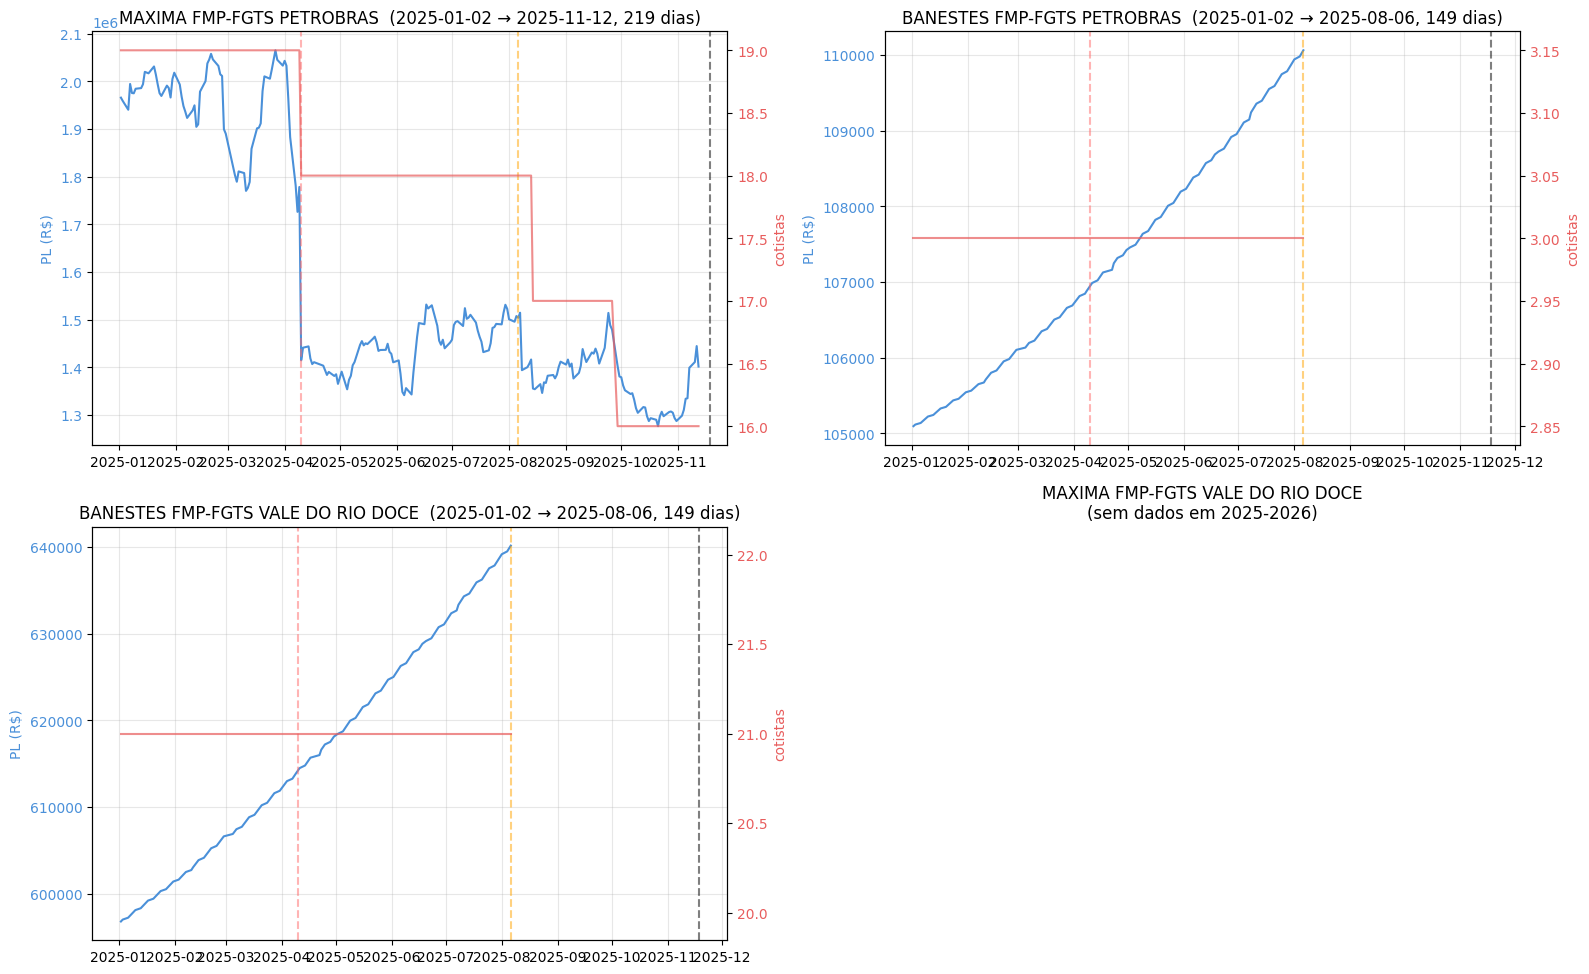

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (cnpj, nome) in zip(axes.flatten(), FMPS.items()):
    df = inf[inf['fundo_cnpj'] == cnpj].sort_values('data')
    if df.empty:
        ax.set_title(f'{nome}\n(sem dados em 2025-2026)')
        ax.axis('off')
        continue
    ax.plot(df['data'], df['pl'], color='#4A90D9', linewidth=1.5)
    ax.set_ylabel('PL (R$)', color='#4A90D9')
    ax.tick_params(axis='y', labelcolor='#4A90D9')
    ax2 = ax.twinx()
    ax2.plot(df['data'], df['cotistas'], color='#E85D5D', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel('cotistas', color='#E85D5D')
    ax2.tick_params(axis='y', labelcolor='#E85D5D')
    ax2.grid(False)
    for d, lb, c in [('2025-04-10', 'resgate', '#FF6B6B'),
                     ('2025-08-06', 'BANESTES off', '#FFA500'),
                     ('2025-11-18', 'liquid BACEN', '#000000')]:
        ax.axvline(pd.Timestamp(d), color=c, linestyle='--', alpha=0.5)
    ax.set_title(f'{nome[:50]}  ({df["data"].min().date()} → {df["data"].max().date()}, {len(df)} dias)')
plt.tight_layout()
plt.show()

In [13]:
resgates = pd.read_sql('''
    SELECT i.data, i.fundo_cnpj, e.razao_social AS fundo,
           i.resgate_dia, i.cotistas, i.pl
    FROM inf_diario i
    LEFT JOIN empresas e ON e.cnpj = i.fundo_cnpj
    WHERE i.resgate_dia >= 50000
    ORDER BY i.resgate_dia DESC
''', con)
print('Resgates atípicos (≥ R$ 50 mil em um único dia):')
resgates

Resgates atípicos (≥ R$ 50 mil em um único dia):


,data,fundo_cnpj,fundo,resgate_dia,cotistas,pl
0,2025-04-10,02727085000130,MÁXIMA FMP - FGTS PETROBRAS,254334.89,18,1415009.18


## 8. Composição da Carteira — onde o KATCH→UPPER aparece

A tabela `carteira` vem do dataset CVM CDA (Composição da Carteira). Permite ver **em que ativos cada fundo investiu** mês a mês — e a flag `emissor_ligado` indica que a CVM identificou vínculo entre o emissor do ativo e o administrador do fundo.

In [14]:
carteira = pd.read_sql('SELECT * FROM carteira WHERE emissor_nome IS NOT NULL', con)
print(f'posições com emissor identificado: {len(carteira)}')

ligados = carteira[carteira['emissor_ligado'].fillna('N').str.upper().eq('S')]
print(f'posições marcadas como emissor LIGADO: {len(ligados)}')
ligados[['data_competencia', 'fundo_cnpj', 'emissor_nome', 'emissor_cnpj', 'vl_merc_pos_final']].sort_values('vl_merc_pos_final', ascending=False)

posições com emissor identificado: 8
posições marcadas como emissor LIGADO: 2


,data_competencia,fundo_cnpj,emissor_nome,emissor_cnpj,vl_merc_pos_final
3,2025-08-31,31368739000184,UPPER FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS,28849674000184,32658172.46
7,2025-11-30,31368739000184,UPPER FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS,28849674000184,31002312.82


**Achado-bomba:** o **KATCH FIDC** (CNPJ 31368739000184) tinha **R$ 32 milhões em UPPER FIDC** marcado como emissor ligado em ago/2025 e nov/2025. KATCH é administrado pela Master Corretora; UPPER nem aparece no `cad_fi.csv` da CVM.

Comparativo com o resto da carteira do KATCH:

In [15]:
katch = pd.read_sql('''
    SELECT data_competencia, emissor_nome, emissor_ligado,
           ROUND(vl_merc_pos_final, 2) AS valor
    FROM carteira
    WHERE fundo_cnpj = '31368739000184'
    ORDER BY data_competencia, valor DESC
''', con)
katch

,data_competencia,emissor_nome,emissor_ligado,valor
0,2025-08-31,UPPER FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS,S,32658172.46
1,2025-08-31,BTG PACTUAL TESOURO SELIC FUNDO DE INVESTIMENTO RENDA FIXA REFERENCIADO DI,N,117059.88
2,2025-08-31,NaN,N,10573.21
3,2025-08-31,NaN,N,8892.99
4,2025-08-31,NaN,N,4914.89
5,2025-08-31,FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS PREMIER,N,0.00
6,2025-11-30,UPPER FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS,S,31002312.82
7,2025-11-30,BTG PACTUAL TESOURO SELIC FUNDO DE INVESTIMENTO RENDA FIXA REFERENCIADO DI,N,85216.71
8,2025-11-30,NaN,N,10831.42
9,2025-11-30,NaN,N,10668.67


## 9. Sanções CVM — quem do nosso dataset já foi acusado?

Cruzamento com a base CVM de Processo Sancionador. Pergunta: alguma das 104 pessoas físicas no nosso QSA já foi acusada em PAS?

In [16]:
matches_pessoas = pd.read_sql('''
    SELECT DISTINCT s.nome AS pessoa_master,
           a.nup, a.situacao, a.data_situacao,
           (SELECT objeto FROM cvm_processos p WHERE p.nup = a.nup) AS objeto
    FROM cvm_acusados a
    JOIN pessoas s ON UPPER(a.nome_acusado) = UPPER(s.nome)
''', con)
print(f'pessoas do nosso QSA acusadas em PAS-CVM: {len(matches_pessoas)}')
matches_pessoas

pessoas do nosso QSA acusadas em PAS-CVM: 12


,pessoa_master,nup,situacao,data_situacao,objeto
0,ANGELO ANTONIO RIBEIRO DA SILVA,19957006441202187,Acusado envia proposta de Termo de Compromisso,2022-03-31,Apurar a responsabilidade do Banco Máxima S.A. e Angelo Antonio Ribeiro da S...
1,ARTUR MARTINS DE FIGUEIREDO,19957002964202073,GCP intima acusado da absolvição em 1a instância,2026-03-24,Apurar as responsabilidades da PLANNER CORRETORA DE VALORES S.A.. e do Sr. A...
2,ARTUR MARTINS DE FIGUEIREDO,19957003519202110,Acusado não apresenta proposta de Termo de Compromisso,2025-02-26,Apurar irregularidades relacionadas ao funcionamento dos Fundos de Investime...
3,ARTUR MARTINS DE FIGUEIREDO,19957008143201826,GCP intima acusado da absolvição em 1a instância,2024-03-20,Apurar irregularidades detectadas atreladas a emissão e distribuição de debê...
4,ARTUR MARTINS DE FIGUEIREDO,19957008816201848,GCP intima acusado da absolvição em 2a instância (CRSFN),2025-03-11,Apurar irregularidades detectadas atreladas a emissão e distribuição de debê...
5,ARTUR MARTINS DE FIGUEIREDO,19957010958201875,Acusado envia defesa,2019-07-08,Apurar irregularidades detectadas atreladas a emissão e distribuição de debê...
6,DANIEL BUENO VORCARO,19957007976202094,Acusado envia proposta de Termo de Compromisso,2021-10-29,Apurar irregularidades detectadas atreladas a emissão e distribuição de cota...
7,DANIEL BUENO VORCARO,19957009798201901,Acusado tem Termo de Compromisso aceito,2020-12-01,"Termo de Acusação - CENTARA INVESTIMENTOS E PARTICIPAÇÕES S.A., SR. MARCIO A..."
8,DAVID JESUS GIL FERNANDEZ,19957009152201834,GCP intima acusado da condenação em 2a instância (CRSFN) e envio da GRU para...,2025-06-12,Apuração de suspeitas de irregularidades em operações realizadas com contrat...
9,LUIZ ANTONIO BULL,19957003570202032,Acusado envia proposta de Termo de Compromisso,2024-11-14,"Apuração dos indícios de irregularidades e de infração às normas da CVM, na ..."


In [17]:
maxima_pas = pd.read_sql('''
    SELECT nup, data_abertura, fase_atual, SUBSTR(objeto, 1, 200) AS objeto
    FROM cvm_processos
    WHERE UPPER(objeto) LIKE '%MAXIMA%' OR UPPER(ementa) LIKE '%MAXIMA%'
    ORDER BY data_abertura
''', con)
print(f'processos CVM mencionando "MAXIMA" (gestora parceira #1 do Master): {len(maxima_pas)}')
maxima_pas

processos CVM mencionando "MAXIMA" (gestora parceira #1 do Master): 0


,nup,data_abertura,fase_atual,objeto


## 10. Cruzamentos investigativos

Algumas queries-âncora pra você adaptar.

In [18]:
pd.read_sql('''
    SELECT e.razao_social, p.qualificacao, p.data_entrada
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    WHERE s.nome LIKE '%VORCARO%'
    ORDER BY p.data_entrada
''', con)

,razao_social,qualificacao,data_entrada
0,VIKING PARTICIPACOES LTDA,Sócio,2006-02-15
1,BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL,Presidente,2017-12-01
2,BANCO MASTER DE INVESTIMENTO S.A.- EM LIQUIDACAO EXTRAJUDICIAL,Presidente,2025-08-12


In [19]:
pd.read_sql('''
    SELECT e.razao_social, p.qualificacao, p.data_entrada
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    WHERE s.nome LIKE '%QUADRADO%'
    ORDER BY p.data_entrada
''', con)

,razao_social,qualificacao,data_entrada
0,TRUSTEE DISTRIBUIDORA DE TITULOS E VALORES MOBILIARIOS LTDA,Sócio,2021-06-02
1,TRUSTEE HOLDING FINANCEIRA S/A,Diretor,2022-12-05
2,BANCO LETSBANK S.A.- EM LIQUIDACAO EXTRAJUDICIAL,Presidente,2024-11-01


In [20]:
CNPJS_MASTER_NUCLEO = (
    '33923798000100', '33884941000194', '09526594000143',
    '58497702000102', '07875796000175', '33886862000112',
)
CNPJS_GESTORAS = (
    '03566273000196', '18223260000191', '09121454000195', '21180163000173',
    '18167777000100', '47917164000141', '42373402000181', '50543106000100',
    '24515907000151',
)

ph_m = ','.join('?' * len(CNPJS_MASTER_NUCLEO))
ph_g = ','.join('?' * len(CNPJS_GESTORAS))
comuns = pd.read_sql(f'''
    WITH m AS (
        SELECT DISTINCT s.nome FROM participacoes p
        JOIN pessoas s ON s.id = p.socio_pessoa_id
        WHERE p.empresa_cnpj IN ({ph_m})
    ),
    g AS (
        SELECT DISTINCT s.nome FROM participacoes p
        JOIN pessoas s ON s.id = p.socio_pessoa_id
        WHERE p.empresa_cnpj IN ({ph_g})
    )
    SELECT m.nome FROM m JOIN g ON m.nome = g.nome
''', con, params=CNPJS_MASTER_NUCLEO + CNPJS_GESTORAS)

print(f'PF em comum entre núcleo Master e gestoras parceiras: {len(comuns)}')
comuns

PF em comum entre núcleo Master e gestoras parceiras: 2


,nome
0,JOSE RICARDO DE QUEIROZ PEREIRA
1,VIVIANE APARECIDA RODRIGUES AFONSO


## 11. Próximas perguntas pra você explorar

Coisas que o dataset atual já permite responder e que ainda não foram totalmente investigadas:

1. **Quem é Adriano Garzon Correa, fora do nosso dataset?** Ele entrou na Viking em 29/09/2025 sem aparecer em outras entidades Master. Vale buscar trajetória externa.
2. **A Trustee Holding tem outras conexões com o grupo Master?** Mauricio Quadrado é só uma. Veja `socios_da('TRUSTEE')` pra listar todos os outros sócios.
3. **Em que mais o KATCH→UPPER aparece?** Coletar mais meses do CDA (basta editar `PERIODOS` em `coleta/cvm_carteira.py`) e ver se a posição existe desde 2024 ou só nasceu em 2025.
4. **Algum dos 53 fundos não-FMP também tem `emissor_ligado=S`?** Mesma fonte (CDA), expandir o filtro.
5. **Algum dos políticos citados** (Temer, ACM Neto, Antônio de Rueda, Ciro Nogueira) **aparece no QSA de qualquer entidade tangencial**? Cruzar via nomes.
6. **Tirreno** — a empresa de fachada citada na imprensa não está no nosso dataset. Vale puxar QSA dela: precisa achar o CNPJ via reportagem.

## 12. Onde continuar

- **Hub geral**: `hub_analise.ipynb` — visão das 104 pessoas com RandomForest Proximity
- **Recorte focado**: `vorcaro_circulo.ipynb` — 11 pessoas no ego de Vorcaro
- **Documento de trabalho**: `RELATORIO.md` (gitignored) — estado da investigação
- **Vocabulário**: `GLOSSARIO.md` (gitignored) — termos do projeto
- **Documentação pública**: `DOCUMENTACAO.md` — síntese do caso e setup

Boa investigação.

In [21]:
con.close()